In [22]:
del ModelPipeline

In [23]:
from build import ModelPipeline

# Initialize pipeline
pipeline = ModelPipeline(target_col="liquidity_stress_next_30d")

# Run automated split, feature extraction, model fitting, and validation evaluation
pipeline.fit_and_evaluate(
    "Train.csv", val_size=0.2, threshold=0.7
)


Reading dataset from: Train.csv
Dataset Split: Train = 32000 rows, Val = 8000 rows


/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"{col}_log"] = np.log1p(np.maximum(0, data[col]))
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"{col}_log"] = np.log1p(np.maximum(0, data[col]))


Features generated: 248 columns. Imbalance Ratio: 5.67

--- Training LightGBM Classifier ---
--- Training CatBoost Classifier ---
--- Training Regularized Logistic Regression ---

[SUCCESS] All Models Fitted!

================ VALIDATION RESULTS ================


NameError: name 'lr_val_probs' is not defined

In [5]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [19]:
with open("training_metrics.pkl", "rb") as f:
    training_metrics = pickle.load(f)

type(training_metrics)

dict

In [20]:
training_metrics.keys()

dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'val_preds'])

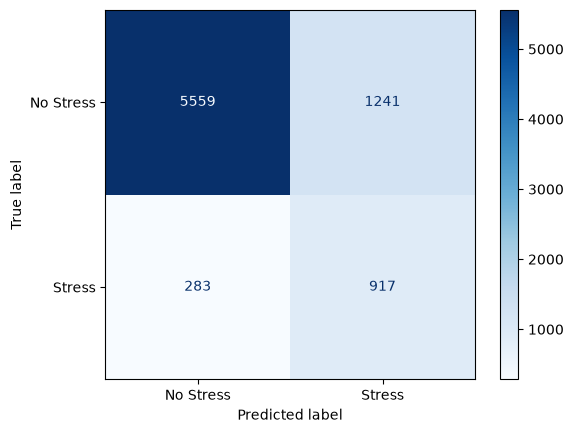

In [21]:
cm = confusion_matrix(training_metrics["y_val"], training_metrics["val_preds"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stress", "Stress"])
disp.plot(cmap="Blues")
plt.show()

In [ ]:
probs, submission = pipeline.test_predict("Test.csv")

Reading dataset from: Test.csv
Test Feature Matrix Shape: (30000, 248)


/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/ml_kernel/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

array([0.3605875 , 0.23832032, 0.21454022, ..., 0.63940091, 0.15263073,
       0.5753105 ], shape=(30000,))

In [17]:
(
    len(training_metrics["y_train"]), sum(training_metrics["y_train"]), 
    (
        len(training_metrics["y_train"]) - sum(training_metrics["y_train"]) 
    )/ sum(training_metrics["y_train"])
)

(32000, 4800, 5.666666666666667)

In [5]:
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.360588
1,ID_29975A9C7E,0.238320
2,ID_F59CE25650,0.214540
3,ID_E875F68D1A,0.148821
4,ID_2902B1C0D0,0.091705
